# Lid-Driven Cavity — PINN Solver
# Physics-Informed Neural Network for 2-D incompressible Navier-Stokes (Re = 100)

In [1]:
import torch
import matplotlib.pyplot as plt

from pinn import PINN, ns_residual, make_boundary_data, make_collocation_points, eval_pde_loss

## Hyperparameters

In [2]:
N_b = 200  # boundary sample points
N_f = 10_000  # collocation (interior) points
N_eval_pde = 2_000  # fresh points for eval L_pde (every 100 epochs)
nu = 0.01  # kinematic viscosity  →  Re = U*L/nu = 100
layers = [2, 64, 64, 64, 64, 3]

lr = 1e-3
num_epochs = 50_000
log_every = 5_000

## Data

In [3]:
x_bc, y_bc, u_bc, v_bc = make_boundary_data(N_b)
x_f,  y_f = make_collocation_points(N_f)

print(f"Boundary points : {x_bc.shape[0]}")
print(f"Collocation pts : {x_f.shape[0]}")

Boundary points : 200
Collocation pts : 10000


## Model

In [ ]:
net = PINN(layers)
opt = torch.optim.Adam(net.parameters(), lr=lr)

loss_history = []
eval_history = []  # (epoch, l_pde_eval, eval_time_ms)
epoch = 0

total_params = sum(p.numel() for p in net.parameters())
print(f"Architecture : {layers}")
print(f"Parameters   : {total_params:,}")

Architecture : [2, 64, 64, 64, 64, 3]
Parameters   : 12,867


## Training

In [ ]:
import time

t_train_start = time.perf_counter()

while epoch < num_epochs:
    epoch += 1
    t_step_start = time.perf_counter()

    opt.zero_grad()

    # Boundary condition loss
    u_p, v_p, _ = net(x_bc, y_bc)
    loss_bc = ((u_p - u_bc)**2 + (v_p - v_bc)**2).mean()

    # PDE residual loss
    r_x, r_y, r_c = ns_residual(net, x_f, y_f, nu)
    loss_pde = (r_x**2 + r_y**2 + r_c**2).mean()

    # Pressure gauge fix: pin p=0 at domain centre
    _, _, p_mid = net(torch.tensor([[0.5]]), torch.tensor([[0.5]]))
    loss_p = p_mid**2

    loss = 10 * loss_bc + loss_pde + 10 * loss_p
    loss.backward()
    opt.step()

    step_ms = (time.perf_counter() - t_step_start) * 1e3
    loss_history.append(loss.item())
    print('.' if epoch % 100 else (str(epoch)+'\n'), end='', flush=True)

    if epoch % 10 == 0:
        t_eval_start = time.perf_counter()
        l_eval = eval_pde_loss(net, nu, N_eval=N_eval_pde)
        eval_ms = (time.perf_counter() - t_eval_start) * 1e3
        eval_history.append((epoch, l_eval, eval_ms))
        if epoch % log_every == 0:
            print(f"\nepoch {epoch:>6d} | train {loss.item():.3e} | eval L_pde {l_eval:.3e} | step {step_ms:.1f}ms | eval {eval_ms:.1f}ms")

print()
total_min = (time.perf_counter() - t_train_start) / 60
print(f"Training complete — {total_min:.1f} min  (epoch:{len(loss_history)-1})")


In [13]:
eval_history

[(0, 0.0011710654944181442, 14.604749856516719),
 (10, 0.013335369527339935, 14.650125056505203),
 (20, 0.002555385697633028, 18.349500140175223),
 (30, 0.008494478650391102, 15.298333950340748),
 (40, 0.002597024431452155, 14.165458967909217),
 (50, 0.003227037377655506, 20.02933295443654),
 (60, 0.003795541822910309, 15.524291899055243),
 (70, 0.00661328062415123, 14.094625134021044),
 (80, 0.012967822141945362, 15.30520897358656),
 (90, 0.026662928983569145, 17.143707955256104),
 (100, 0.057074036449193954, 15.072958078235388),
 (110, 0.08481893688440323, 16.01833407767117),
 (120, 0.07750524580478668, 15.491292113438249),
 (130, 0.056579332798719406, 19.304290879517794),
 (140, 0.04121417924761772, 15.496291918680072),
 (150, 0.042211487889289856, 16.734708100557327),
 (160, 0.03146649897098541, 16.46937499754131),
 (170, 0.030623119324445724, 19.718124996870756),
 (180, 0.025298722088336945, 16.592165920883417),
 (190, 0.03180747479200363, 14.63645906187594),
 (200, 0.026809627190

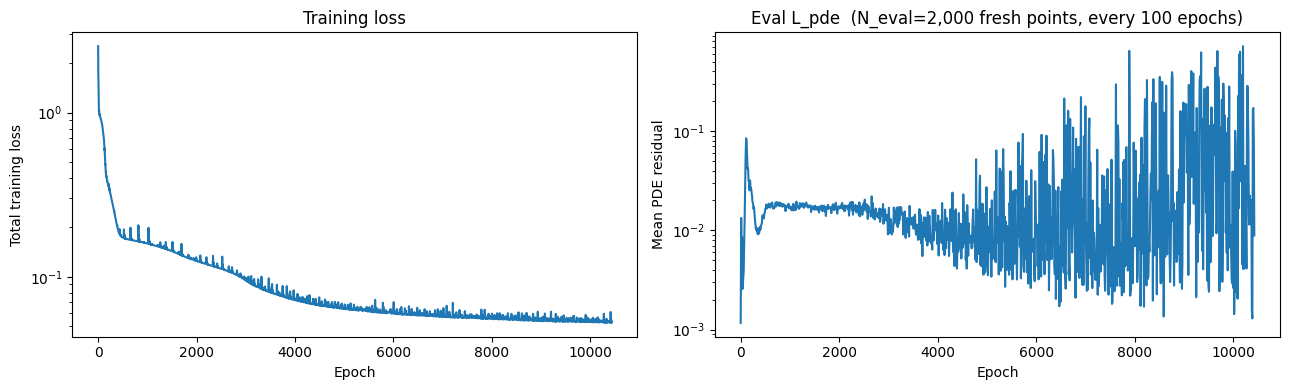

In [14]:
epochs_eval, losses_eval, eval_times_ms = zip(*eval_history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(loss_history)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total training loss")
axes[0].set_title("Training loss")

axes[1].semilogy(epochs_eval, losses_eval)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean PDE residual")
axes[1].set_title(f"Eval L_pde  (N_eval={N_eval_pde:,} fresh points, every 100 epochs)")

plt.tight_layout()
plt.show()

## Inference

In [23]:
x_q = torch.tensor([[0.5]])
y_q = torch.tensor([[0.8]])

with torch.no_grad():
    u_pred, v_pred, p_pred = net(x_q, y_q)

print(f"u = {u_pred.item():.4f}   (expect ~0.72 near lid — Ghia et al.)")
print(f"v = {v_pred.item():.4f}")
print(f"p = {p_pred.item():.4f}")

u = 0.0805   (expect ~0.72 near lid — Ghia et al.)
v = 0.0925
p = -0.0449


## Visualization

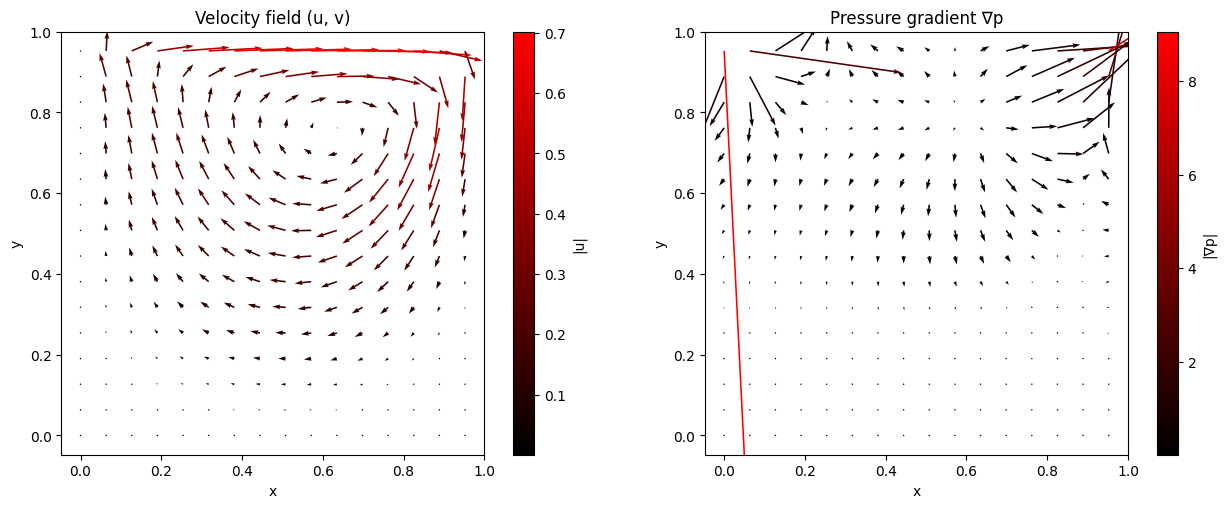

In [26]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

black_red = LinearSegmentedColormap.from_list("black_red", ["black", "red"])

# Evaluate on a regular 64x64 grid
N = 64
step = 4  # quiver subsampling → 16×16 arrows
xs = torch.linspace(0, 1, N)
ys = torch.linspace(0, 1, N)
X, Y = torch.meshgrid(xs, ys, indexing="ij")

with torch.no_grad():
    U, V, P = net(X.reshape(-1, 1), Y.reshape(-1, 1))

U = U.reshape(N, N).numpy()
V = V.reshape(N, N).numpy()
P = P.reshape(N, N).numpy()

# grad(p) via finite differences on the grid
dP_dx, dP_dy = np.gradient(P, xs.numpy(), ys.numpy())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Left: velocity quiver coloured by speed
speed = np.sqrt(U**2 + V**2)
q0 = axes[0].quiver(
    xs[::step].numpy(),
    ys[::step].numpy(),
    U[::step, ::step].T,
    V[::step, ::step].T,
    speed[::step, ::step].T.flatten(),
    cmap=black_red,
)
plt.colorbar(q0, ax=axes[0], label="|u|")
axes[0].set_title("Velocity field (u, v)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

# Right: grad(p) quiver coloured by magnitude
mag = np.sqrt(dP_dx**2 + dP_dy**2)
q1 = axes[1].quiver(
    xs[::step].numpy(),
    ys[::step].numpy(),
    dP_dx[::step, ::step].T,
    dP_dy[::step, ::step].T,
    mag[::step, ::step].T.flatten(),
    cmap=black_red,
)
plt.colorbar(q1, ax=axes[1], label="|∇p|")
axes[1].set_title("Pressure gradient ∇p")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()